## make a connection to the database

In [3]:
import pandas as pd
import sqlite3
connection = sqlite3.connect('../../data/checking-logs.sqlite')

df = pd.io.sql.read_sql('SELECT DATE(datetime) as datetime FROM pageviews WHERE uid LIKE "user%"', connection)
df

,datetime
0,2020-04-17
1,2020-04-18
2,2020-04-18
3,2020-04-18
4,2020-04-18
...,...
982,2020-05-21
983,2020-05-21
984,2020-05-21
985,2020-05-22


## using Pandas, create a new dataframe

In [4]:
df = pd.io.sql.read_sql('''WITH only_users AS (SELECT DATE(datetime) as datetime FROM pageviews WHERE uid LIKE "user%")
SELECT
  DATE(datetime) AS visit_date,
  COUNT(*) AS visit_count
FROM only_users
GROUP BY DATE(datetime)
ORDER BY visit_date;''',connection)
df

,visit_date,visit_count
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


## using Pandas method .plot(), create a graph

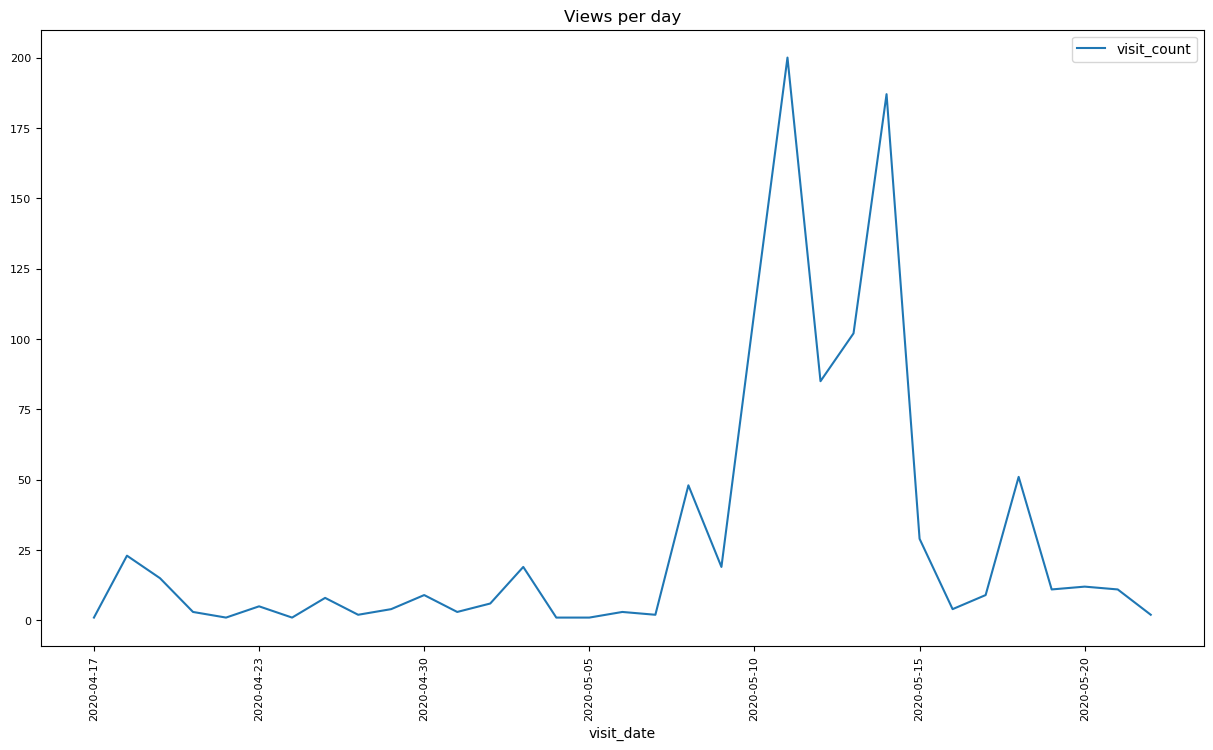

In [5]:
graph = df.plot(kind='line', fontsize=8, figsize=(15, 8), title='Views per day', x='visit_date', y='visit_count')
graph.tick_params(axis='x', rotation=90)

In [6]:
connection.close()